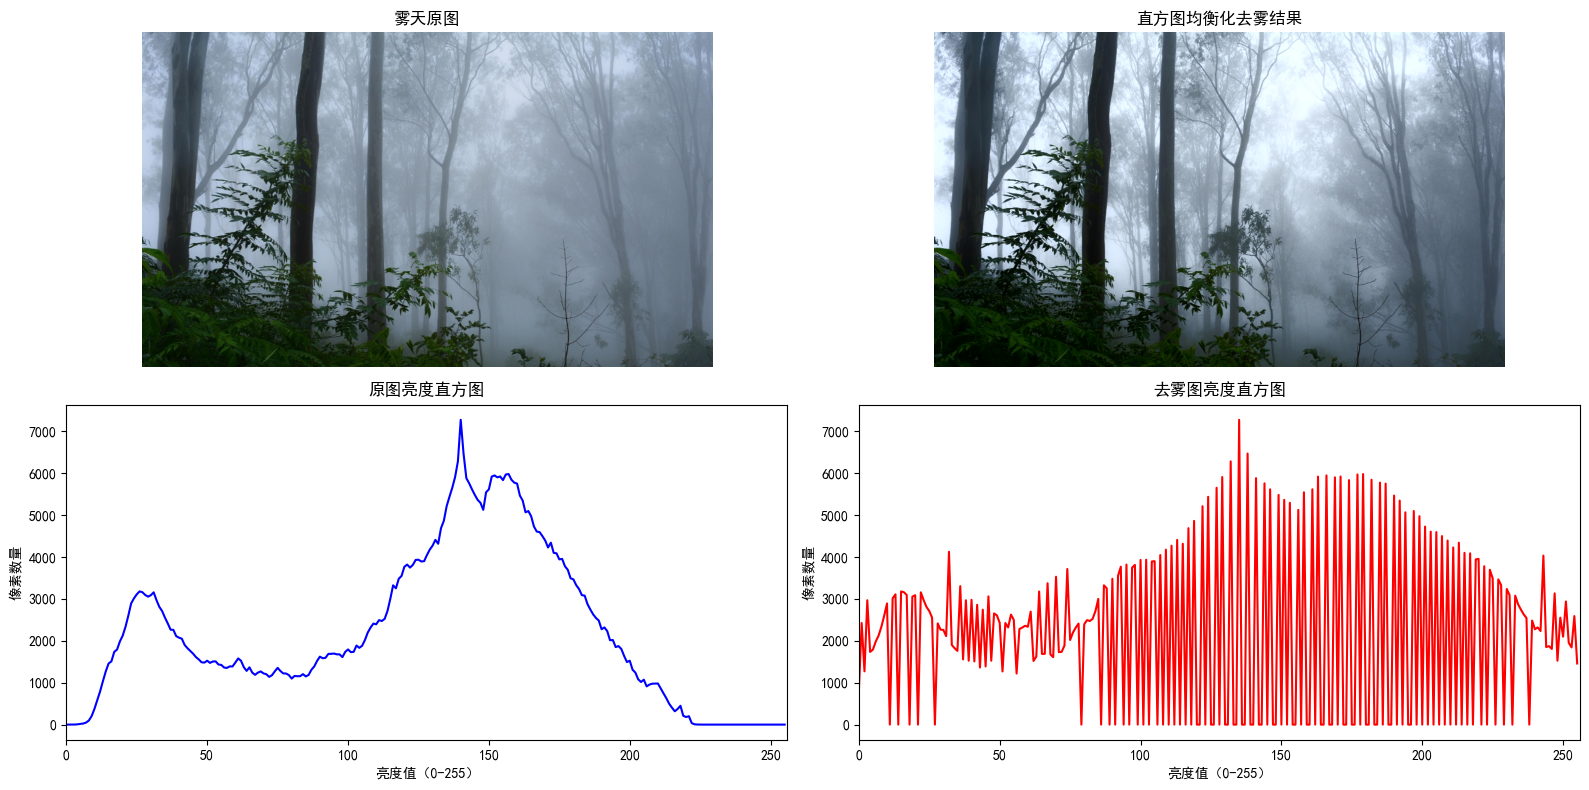

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def histogram_dehazing(img_path):
    """
    直方图均衡化图像去雾
    :param img_path: 雾天图像路径
    :return: 原图、去雾图、原图直方图、去雾图直方图
    """
    # 读取图像
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("图像路径错误或文件不存在！")

    # 转换为YCrCb，分离亮度通道
    ycrcb_img = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    y_channel, cr_channel, cb_channel = cv2.split(ycrcb_img)

    # 亮度通道直方图均衡化
    eq_y_channel = cv2.equalizeHist(y_channel)

    # 合并通道，转回BGR
    eq_ycrcb_img = cv2.merge([eq_y_channel, cr_channel, cb_channel])
    dehazed_img = cv2.cvtColor(eq_ycrcb_img, cv2.COLOR_YCrCb2BGR)

    # 计算亮度直方图
    hist_original = cv2.calcHist([y_channel], [0], None, [256], [0, 256])
    hist_dehazed = cv2.calcHist([eq_y_channel], [0], None, [256], [0, 256])

    return img, dehazed_img, hist_original, hist_dehazed

# 测试代码
img_path = "foggy_image.png"

try:
    original_img, dehazed_img, hist_ori, hist_dehaze = histogram_dehazing(img_path)

    # 可视化
    plt.figure(figsize=(16, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("雾天原图", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(dehazed_img, cv2.COLOR_BGR2RGB))
    plt.title("直方图均衡化去雾结果", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.plot(hist_ori, color="blue")
    plt.title("原图亮度直方图", fontsize=12)
    plt.xlabel("亮度值（0-255）")
    plt.ylabel("像素数量")
    plt.xlim([0, 256])

    plt.subplot(2, 2, 4)
    plt.plot(hist_dehaze, color="red")
    plt.title("去雾图亮度直方图", fontsize=12)
    plt.xlabel("亮度值（0-255）")
    plt.ylabel("像素数量")
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"运行错误：{e}")